In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


In [2]:
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import HeatMap, MarkerCluster
import warnings
warnings.filterwarnings('ignore')


In [3]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import json

In [8]:
df = pd.read_csv("house_prices_srilanka.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'house_prices_srilanka.csv'

In [6]:
df.shape


(20000, 14)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   district           20000 non-null  str  
 1   area               20000 non-null  str  
 2   perch              20000 non-null  int64
 3   bedrooms           20000 non-null  int64
 4   bathrooms          20000 non-null  int64
 5   kitchen_area_sqft  20000 non-null  int64
 6   parking_spots      20000 non-null  int64
 7   has_garden         20000 non-null  bool 
 8   has_ac             20000 non-null  bool 
 9   water_supply       20000 non-null  str  
 10  electricity        20000 non-null  str  
 11  floors             20000 non-null  int64
 12  year_built         20000 non-null  int64
 13  price_lkr          20000 non-null  int64
dtypes: bool(2), int64(8), str(4)
memory usage: 1.9 MB


In [8]:
df.describe()

,perch,bedrooms,bathrooms,kitchen_area_sqft,parking_spots,floors,year_built,price_lkr
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04
mean,11.510500,3.901600,3.171650,113.718800,1.141100,1.557150,2004.926550,1.598142e+07
std,8.519719,1.839426,1.530883,69.801873,0.939167,0.628135,11.817353,1.338156e+07
min,2.000000,1.000000,1.000000,35.000000,0.000000,1.000000,1985.000000,1.500000e+06
25%,5.000000,2.000000,2.000000,53.000000,0.000000,1.000000,1995.000000,6.591047e+06
50%,10.000000,4.000000,3.000000,95.000000,1.000000,1.000000,2005.000000,1.206384e+07
75%,16.000000,5.000000,5.000000,161.000000,2.000000,2.000000,2015.000000,2.096723e+07
max,80.000000,7.000000,5.000000,250.000000,3.000000,3.000000,2025.000000,1.500321e+08


In [9]:
print('=== Categorical Columns ===')
for col in ['district', 'water_supply', 'electricity']:
    print(f'\n{col} ({df[col].nunique()} unique):')
    print(df[col].value_counts().head(10).to_string())

=== Categorical Columns ===

district (25 unique):
district
Polonnaruwa    845
Batticaloa     837
Badulla        834
Gampaha        825
Colombo        818
Hambantota     814
Kegalle        810
Kurunegala     810
Kandy          809
Ampara         807

water_supply (3 unique):
water_supply
Both          6767
Pipe-borne    6697
Well          6536

electricity (2 unique):
electricity
Single phase    10037
Three phase      9963


In [10]:
print('=== Missing Values ===')
missing = df.isnull().sum()
if missing.sum() == 0:
    print('No missing values!')
else:
    print(missing[missing > 0])

=== Missing Values ===
No missing values!


In [11]:
print('=== Duplicate Rows ===')
dupes = df.duplicated().sum()
print(f'Duplicates found: {dupes}')
if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Removed. New shape: {df.shape}')

=== Duplicate Rows ===
Duplicates found: 0


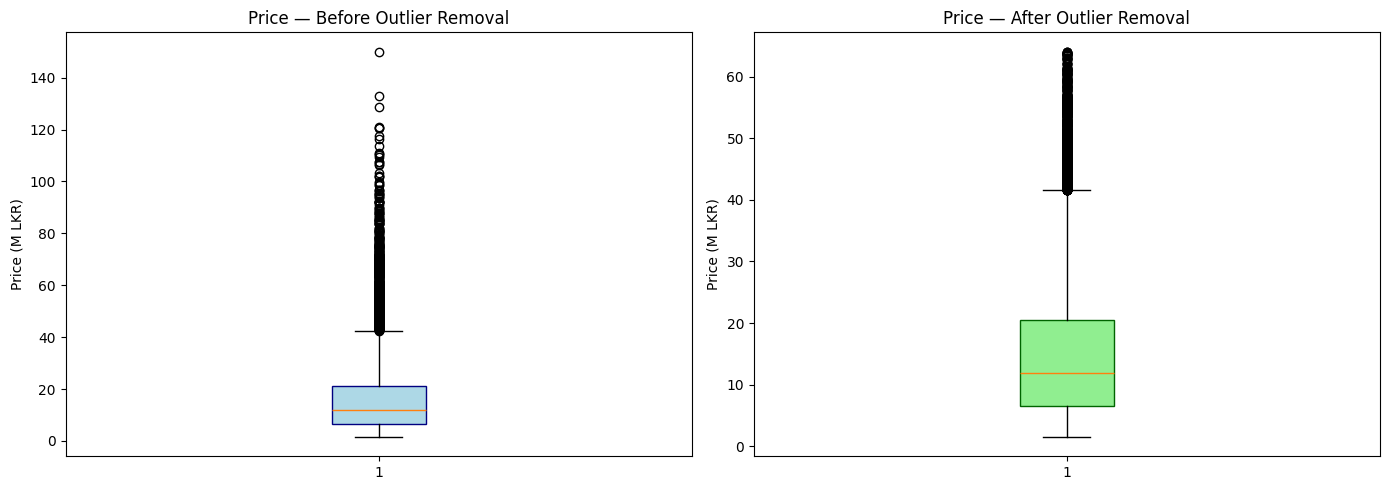

Outliers removed: 227
Clean dataset: 19,773 rows
Price range: 1.50M to 64.06M LKR


In [12]:
# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df['price_lkr'] / 1e6, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'))
axes[0].set_title('Price — Before Outlier Removal')
axes[0].set_ylabel('Price (M LKR)')

# IQR-based outlier removal (3x IQR)
Q1 = df['price_lkr'].quantile(0.25)
Q3 = df['price_lkr'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

outliers_count = df[(df['price_lkr'] < lower_bound) | (df['price_lkr'] > upper_bound)].shape[0]
df_clean = df[(df['price_lkr'] >= lower_bound) & (df['price_lkr'] <= upper_bound)].copy().reset_index(drop=True)

axes[1].boxplot(df_clean['price_lkr'] / 1e6, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', color='darkgreen'))
axes[1].set_title('Price — After Outlier Removal')
axes[1].set_ylabel('Price (M LKR)')

plt.tight_layout()
plt.savefig('outlier_removal.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Outliers removed: {outliers_count}')
print(f'Clean dataset: {df_clean.shape[0]:,} rows')
print(f'Price range: {df_clean["price_lkr"].min()/1e6:.2f}M to {df_clean["price_lkr"].max()/1e6:.2f}M LKR')

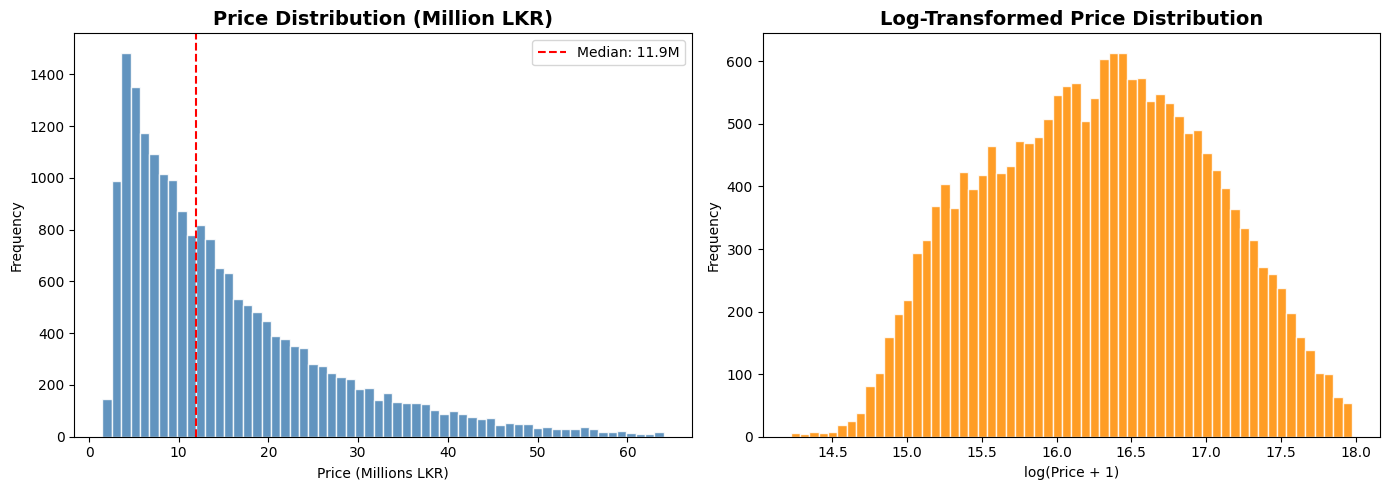

Skewness (raw): 1.406
Skewness (log): -0.016  <-- much better!


In [13]:
# Price distribution: raw vs log
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['price_lkr'] / 1e6, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Price Distribution (Million LKR)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price (Millions LKR)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_clean['price_lkr'].median()/1e6, color='red', linestyle='--',
                label=f'Median: {df_clean["price_lkr"].median()/1e6:.1f}M')
axes[0].legend()

axes[1].hist(np.log1p(df_clean['price_lkr']), bins=60, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Log-Transformed Price Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Skewness (raw): {df_clean["price_lkr"].skew():.3f}')
print(f'Skewness (log): {np.log1p(df_clean["price_lkr"]).skew():.3f}  <-- much better!')

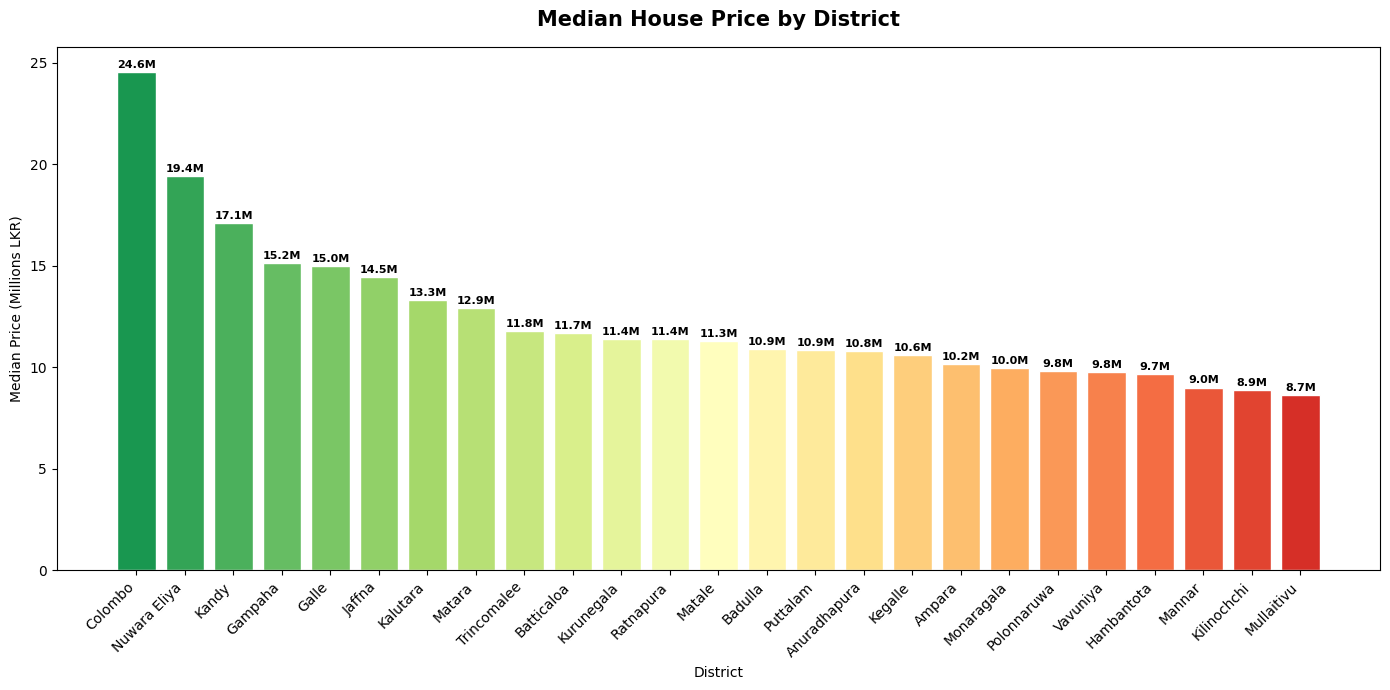

In [14]:
# Median price by district
dist_stats = df_clean.groupby('district')['price_lkr'].median().sort_values(ascending=False) / 1e6

fig, ax = plt.subplots(figsize=(14, 7))
import matplotlib.cm as cm
colors = cm.RdYlGn_r(np.linspace(0.1, 0.9, len(dist_stats)))
bars = ax.bar(dist_stats.index, dist_stats.values, color=colors, edgecolor='white')

for bar, val in zip(bars, dist_stats.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}M', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Median House Price by District', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('District')
ax.set_ylabel('Median Price (Millions LKR)')
ax.set_xticklabels(dist_stats.index, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('price_by_district.png', dpi=150, bbox_inches='tight')
plt.show()

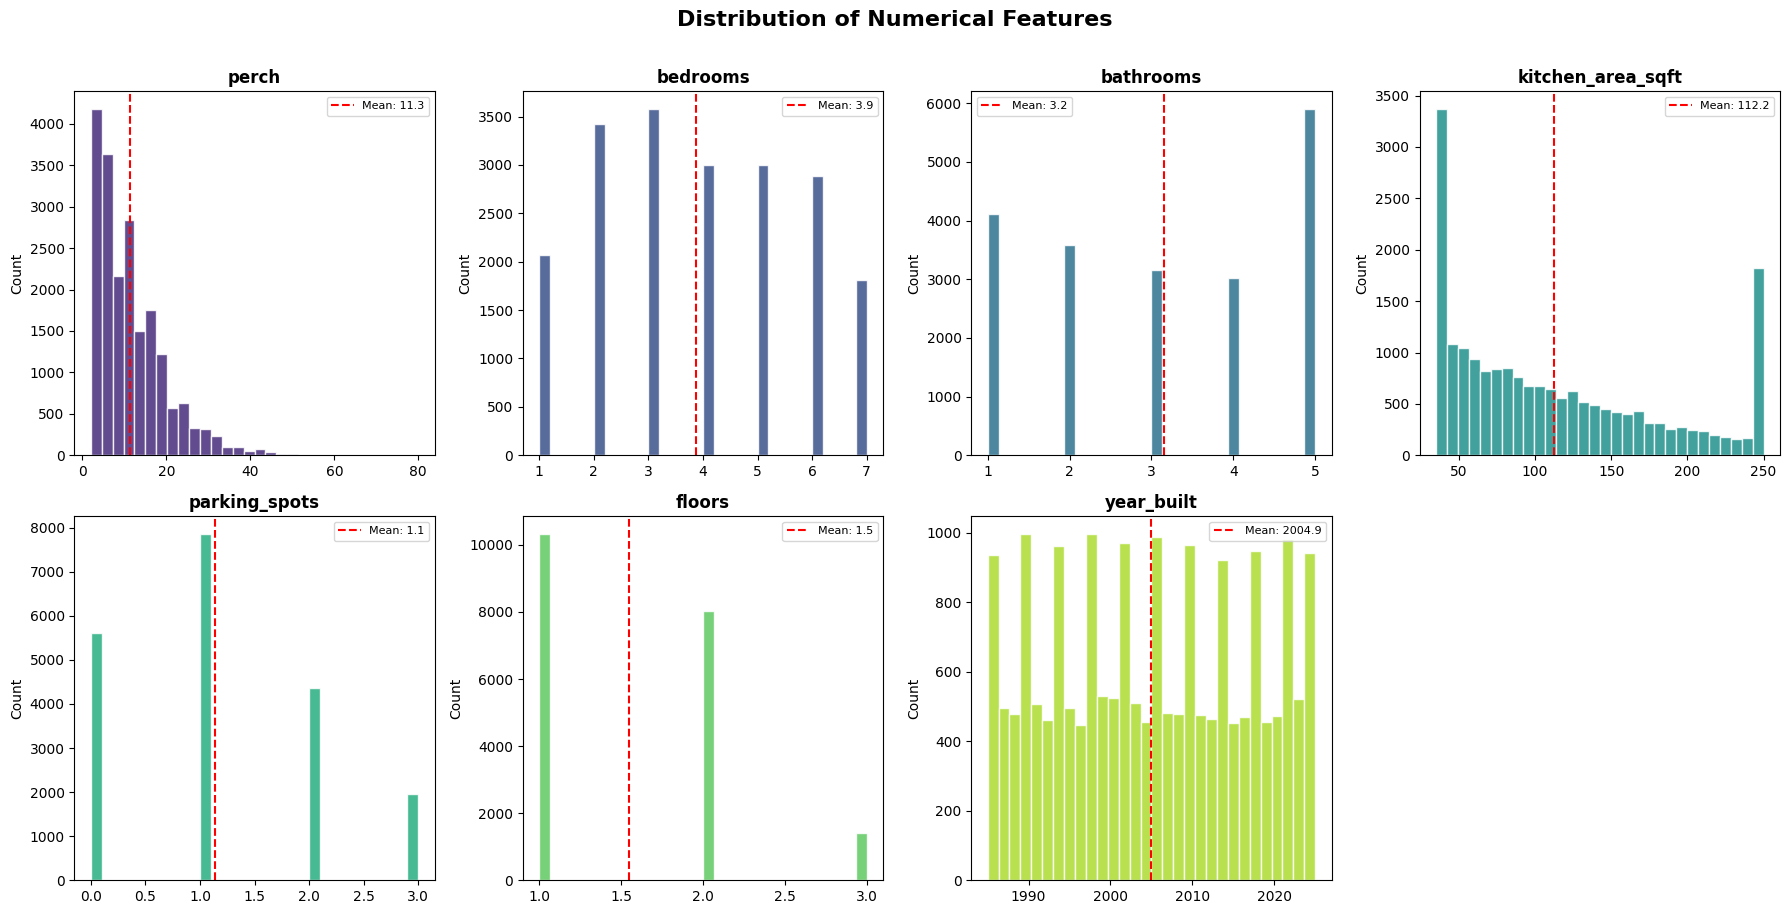

In [15]:
# Numerical features distributions
num_features = ['perch', 'bedrooms', 'bathrooms', 'kitchen_area_sqft', 'parking_spots', 'floors', 'year_built']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
colors = sns.color_palette('viridis', len(num_features))

for i, col in enumerate(num_features):
    axes[i].hist(df_clean[col], bins=30, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Count')
    mean_val = df_clean[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

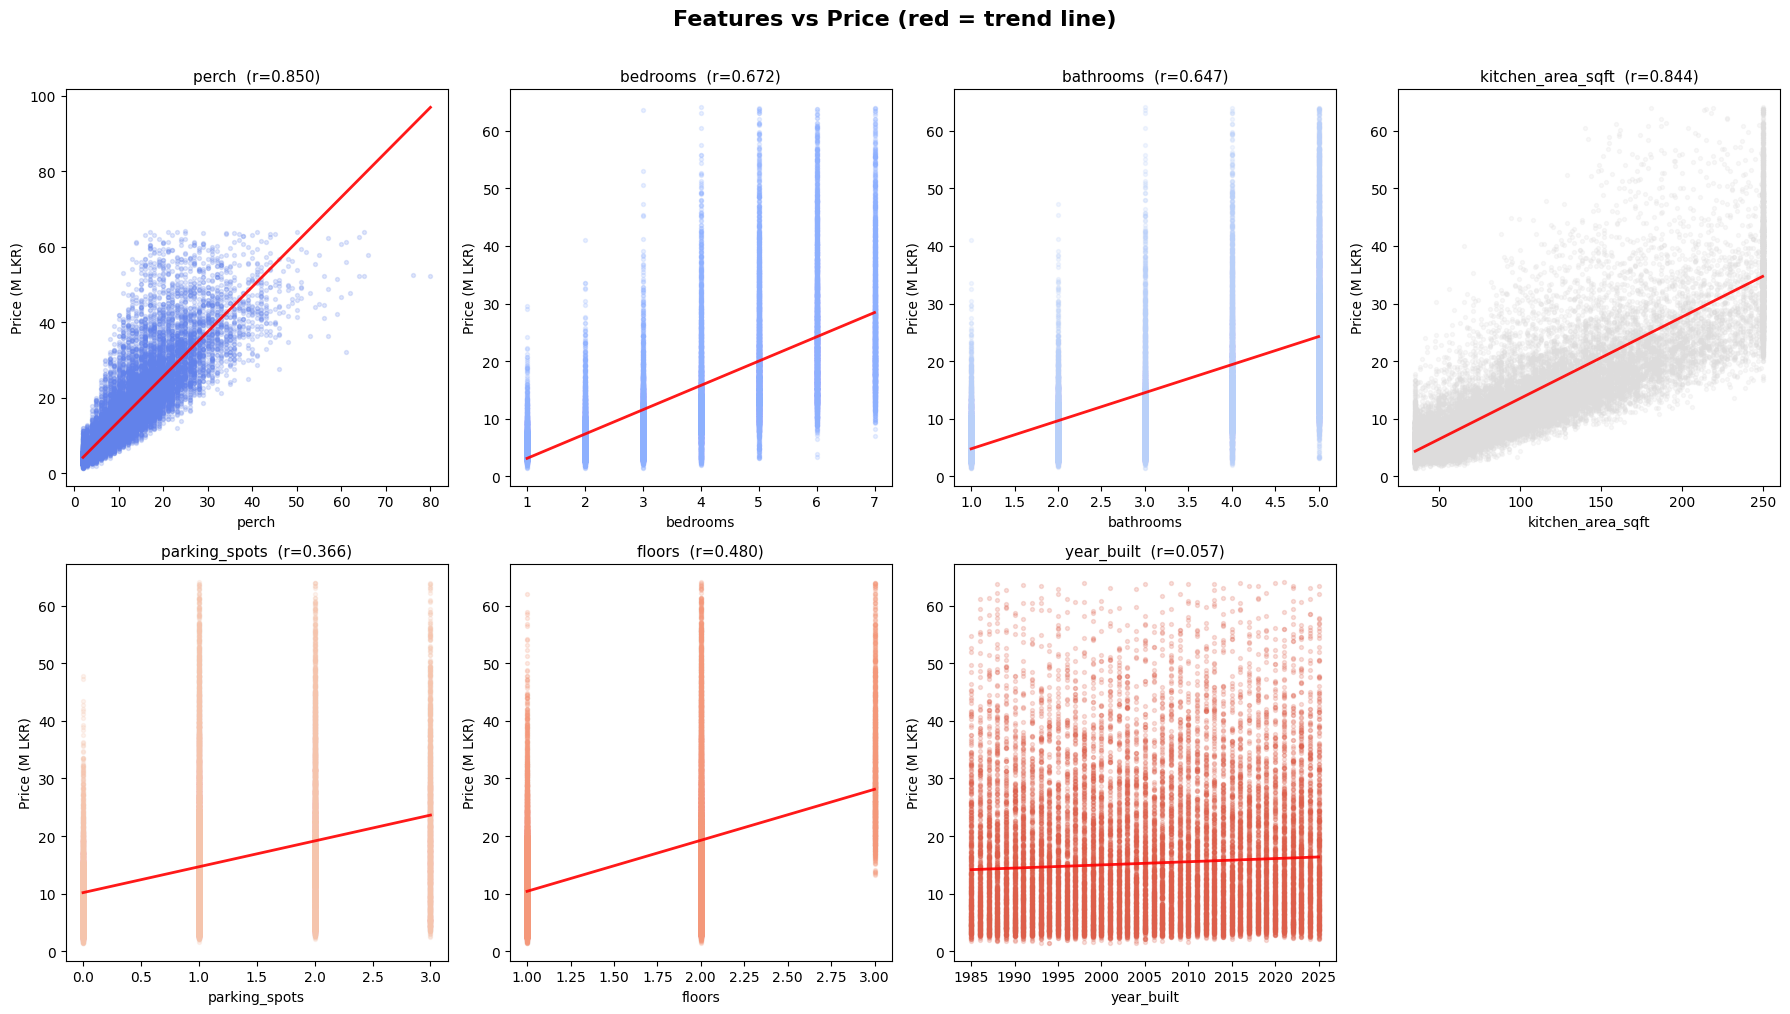

In [22]:
# Scatter: each numerical feature vs price (with trend line)
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
scatter_colors = sns.color_palette('coolwarm', len(num_features))

for i, col in enumerate(num_features):
    axes[i].scatter(df_clean[col], df_clean['price_lkr']/1e6,
                    alpha=0.2, s=8, color=scatter_colors[i])
    z = np.polyfit(df_clean[col], df_clean['price_lkr']/1e6, 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_clean[col].min(), df_clean[col].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r-', linewidth=2, alpha=0.9)
    corr = df_clean[col].corr(df_clean['price_lkr'])
    axes[i].set_title(f'{col}  (r={corr:.3f})', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price (M LKR)')

axes[-1].set_visible(False)
plt.suptitle('Features vs Price (red = trend line)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('features_vs_price_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

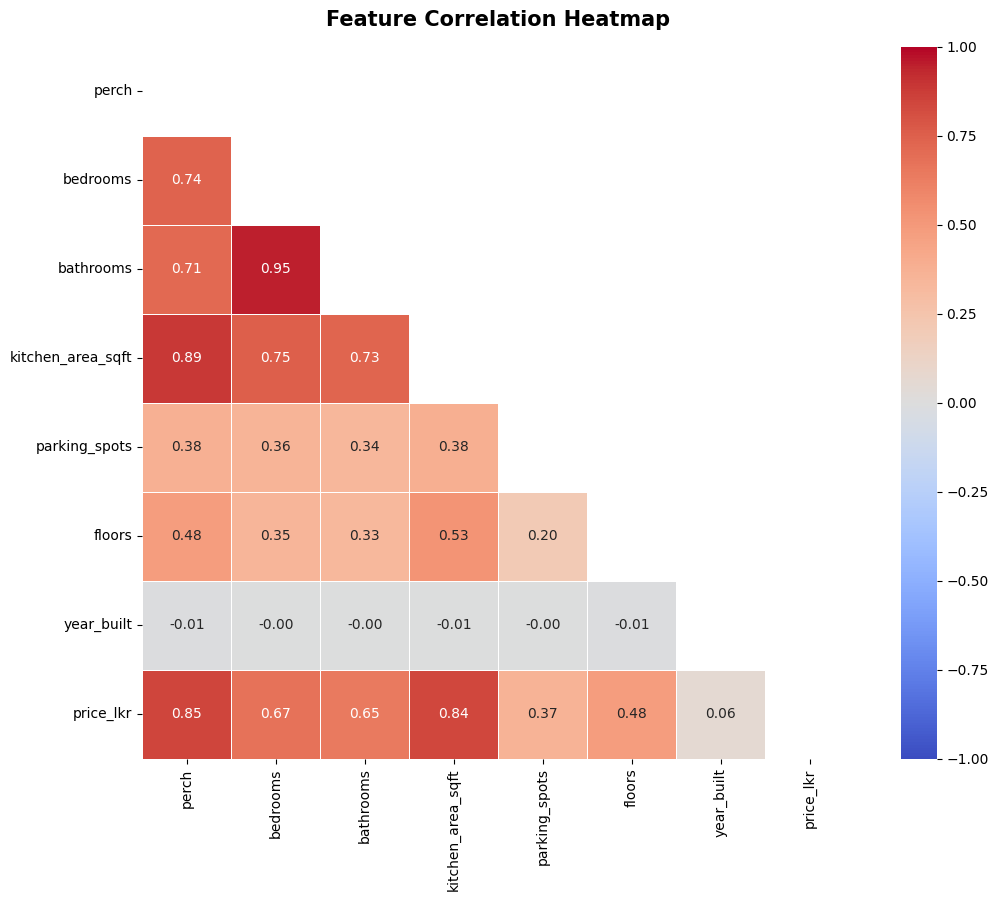

Correlation with price_lkr:
perch                0.849798
kitchen_area_sqft    0.843694
bedrooms             0.672395
bathrooms            0.647182
floors               0.480102
parking_spots        0.365755
year_built           0.056563


In [23]:
# Correlation heatmap
num_cols_heatmap = ['perch', 'bedrooms', 'bathrooms', 'kitchen_area_sqft',
                    'parking_spots', 'floors', 'year_built', 'price_lkr']
corr_matrix = df_clean[num_cols_heatmap].corr()

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5,
            annot_kws={'size': 10}, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

price_corr = corr_matrix['price_lkr'].drop('price_lkr').sort_values(ascending=False)
print('Correlation with price_lkr:')
print(price_corr.to_string())

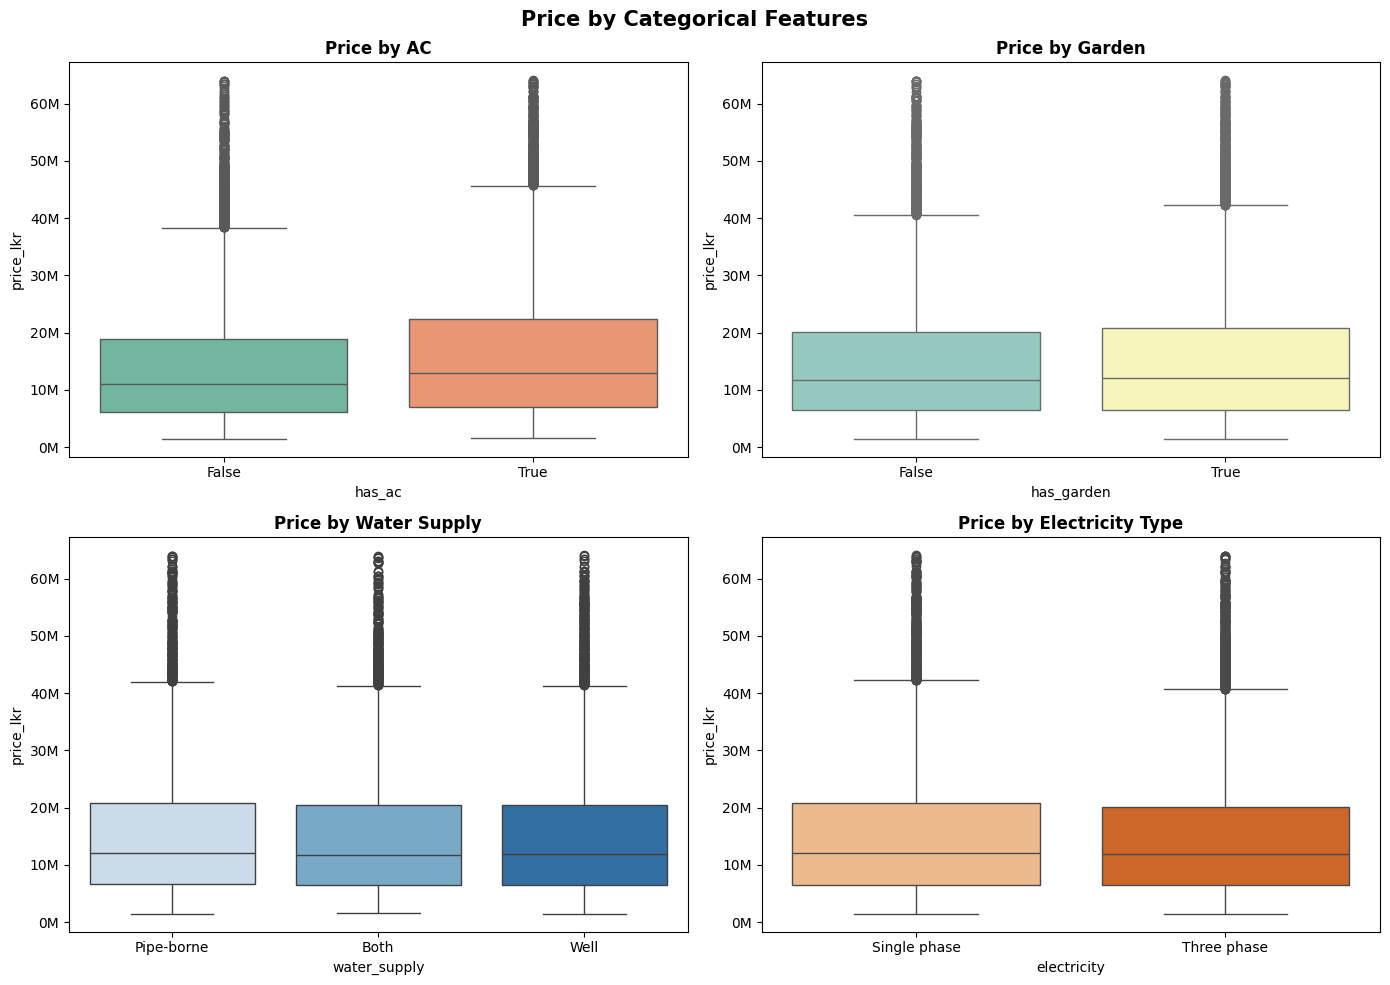

In [24]:
# Boxplots: categorical features vs price
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df_clean, x='has_ac', y='price_lkr', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Price by AC', fontweight='bold')
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

sns.boxplot(data=df_clean, x='has_garden', y='price_lkr', ax=axes[0, 1], palette='Set3')
axes[0, 1].set_title('Price by Garden', fontweight='bold')
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

sns.boxplot(data=df_clean, x='water_supply', y='price_lkr', ax=axes[1, 0], palette='Blues')
axes[1, 0].set_title('Price by Water Supply', fontweight='bold')
axes[1, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

sns.boxplot(data=df_clean, x='electricity', y='price_lkr', ax=axes[1, 1], palette='Oranges')
axes[1, 1].set_title('Price by Electricity Type', fontweight='bold')
axes[1, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.suptitle('Price by Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Plotly interactive: violin by district
fig = px.violin(df_clean, x='district', y='price_lkr', color='district',
                box=True, points=False,
                title='Price Distribution by District (Interactive)',
                labels={'price_lkr': 'Price (LKR)'})
fig.update_yaxes(tickformat='.2s')
fig.update_layout(showlegend=False, xaxis_tickangle=-45, height=500)
fig.show()

In [26]:
# Plotly scatter: perch vs price
fig = px.scatter(df_clean.sample(3000, random_state=42),
                 x='perch', y='price_lkr', color='district', size='bedrooms',
                 hover_data=['area', 'bedrooms', 'bathrooms', 'year_built'],
                 title='Land Size (Perch) vs Price — by District',
                 labels={'price_lkr': 'Price (LKR)', 'perch': 'Land Size (Perch)'},
                 opacity=0.7)
fig.update_yaxes(tickformat='.2s')
fig.update_layout(height=500)
fig.show()

In [27]:
# Year built trend
yearly_price = df_clean.groupby('year_built')['price_lkr'].median() / 1e6

fig = go.Figure()
fig.add_trace(go.Scatter(x=yearly_price.index, y=yearly_price.values,
                         mode='lines+markers', name='Median Price',
                         line=dict(color='steelblue', width=2.5),
                         marker=dict(size=5)))
fig.update_layout(title='Median Price by Year Built',
                  xaxis_title='Year Built', yaxis_title='Median Price (M LKR)', height=400)
fig.show()

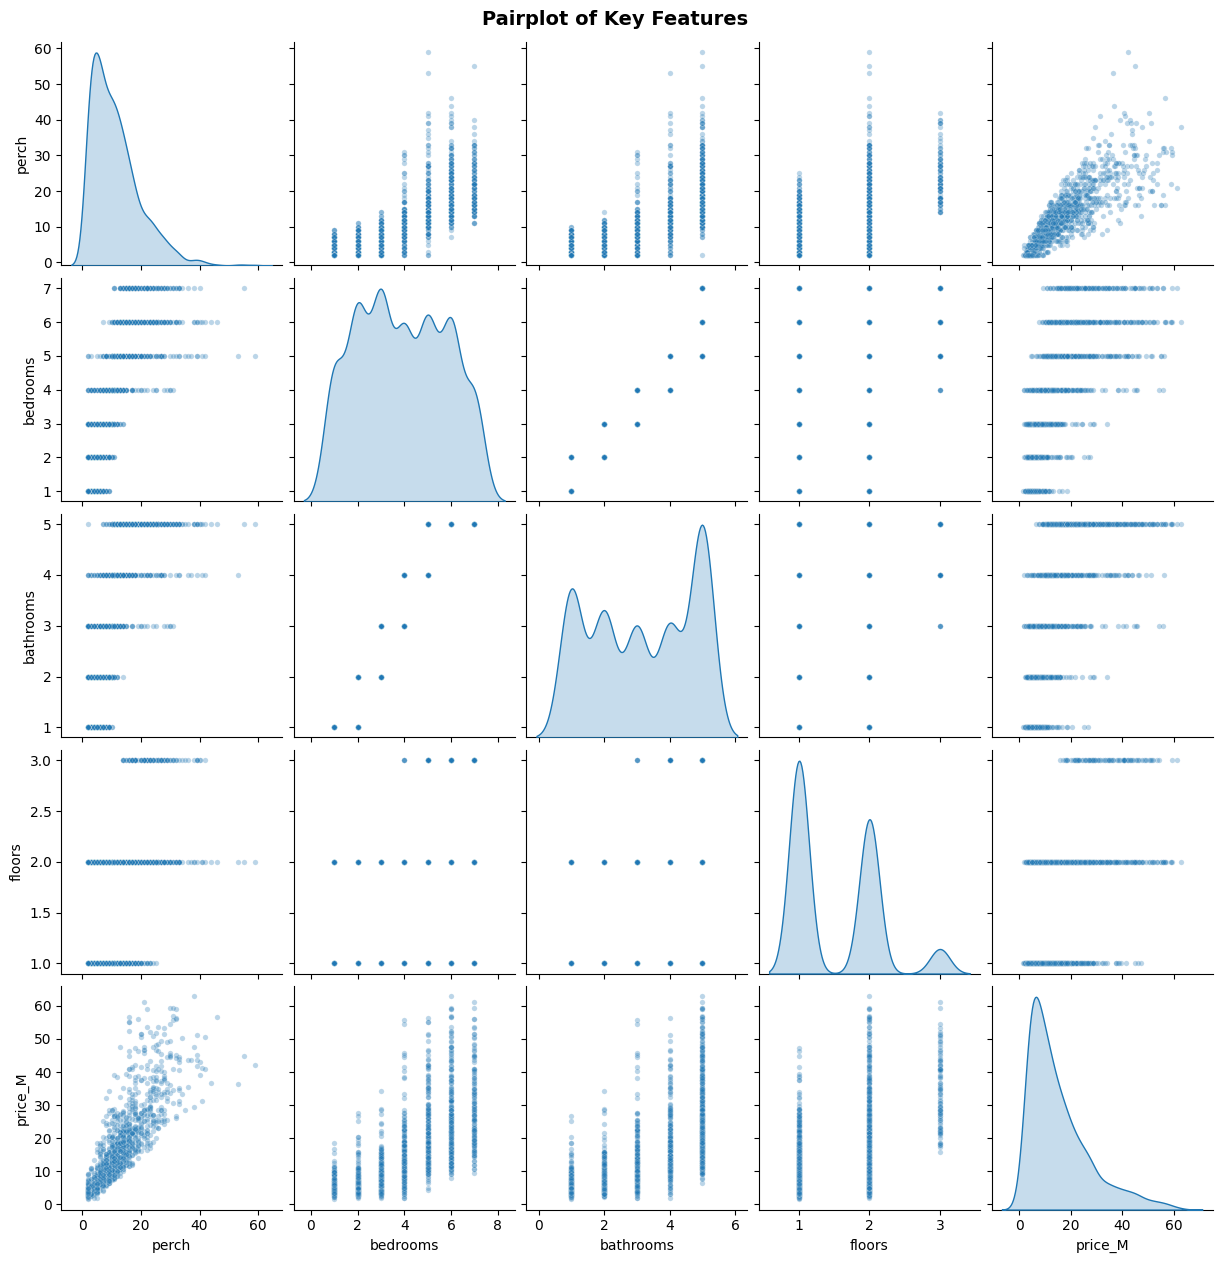

In [28]:
# Pairplot
pairplot_data = df_clean[['perch', 'bedrooms', 'bathrooms', 'floors', 'price_lkr']]\
    .sample(1500, random_state=42).copy()
pairplot_data['price_lkr'] = pairplot_data['price_lkr'] / 1e6
pairplot_data.rename(columns={'price_lkr': 'price_M'}, inplace=True)

g = sns.pairplot(pairplot_data, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 15})
g.fig.suptitle('Pairplot of Key Features', y=1.01, fontsize=14, fontweight='bold')
plt.savefig('pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

In [29]:
import matplotlib.cm as cm

district_coords = {
    'Colombo': (6.9271, 79.8612), 'Gampaha': (7.0840, 80.0098),
    'Kalutara': (6.5854, 79.9607), 'Kandy': (7.2906, 80.6337),
    'Matale': (7.4675, 80.6234), 'Nuwara Eliya': (6.9497, 80.7891),
    'Galle': (6.0535, 80.2210), 'Matara': (5.9549, 80.5550),
    'Hambantota': (6.1241, 81.1185), 'Jaffna': (9.6615, 80.0255),
    'Kilinochchi': (9.3803, 80.4036), 'Mannar': (8.9810, 79.9044),
    'Vavuniya': (8.7514, 80.4973), 'Mullaitivu': (9.2671, 80.8124),
    'Batticaloa': (7.7102, 81.6924), 'Ampara': (7.2992, 81.6747),
    'Trincomalee': (8.5874, 81.2152), 'Kurunegala': (7.4818, 80.3609),
    'Puttalam': (8.0362, 79.8283), 'Anuradhapura': (8.3114, 80.4037),
    'Polonnaruwa': (7.9403, 81.0188), 'Badulla': (6.9934, 81.0550),
    'Moneragala': (6.8728, 81.3507), 'Ratnapura': (6.6828, 80.3992),
    'Kegalle': (7.2513, 80.3464)
}

dist_agg = df_clean.groupby('district').agg(
    median_price=('price_lkr', 'median'),
    avg_price=('price_lkr', 'mean'),
    count=('price_lkr', 'count'),
    avg_perch=('perch', 'mean'),
    avg_bedrooms=('bedrooms', 'mean')
).reset_index()

prices = dist_agg['median_price'].values
norm_prices = (prices - prices.min()) / (prices.max() - prices.min())
colormap = cm.get_cmap('RdYlGn_r')

m = folium.Map(location=[7.8731, 80.7718], zoom_start=7, tiles='CartoDB positron')

for idx, row in dist_agg.iterrows():
    d = row['district']
    if d in district_coords:
        lat, lon = district_coords[d]
        price_M = row['median_price'] / 1e6
        rgba = colormap(norm_prices[idx])
        hex_color = '#{:02x}{:02x}{:02x}'.format(int(rgba[0]*255), int(rgba[1]*255), int(rgba[2]*255))
        radius = max(10, min(40, row['count'] / 40))

        popup_html = f"""
        <div style='width:180px;font-family:Arial'>
            <h4 style='margin:0;color:#333'>{d}</h4><hr style='margin:4px 0'>
            <b>Median Price:</b> {price_M:.2f}M LKR<br>
            <b>Avg Price:</b> {row['avg_price']/1e6:.2f}M LKR<br>
            <b>Listings:</b> {row['count']:,}<br>
            <b>Avg Perch:</b> {row['avg_perch']:.1f}<br>
            <b>Avg Bedrooms:</b> {row['avg_bedrooms']:.1f}
        </div>"""

        folium.CircleMarker(
            location=[lat, lon], radius=radius,
            color='white', weight=1.5,
            fill=True, fill_color=hex_color, fill_opacity=0.85,
            popup=folium.Popup(popup_html, max_width=200),
            tooltip=f"{d}: {price_M:.1f}M LKR"
        ).add_to(m)

m.save('srilanka_house_price_map.html')
print('Map saved: srilanka_house_price_map.html')
m

Map saved: srilanka_house_price_map.html


In [16]:
df_model = df_clean.copy()

# Feature engineering
df_model['house_age']      = 2025 - df_model['year_built']
df_model['bed_bath_ratio'] = df_model['bedrooms'] / (df_model['bathrooms'] + 1)
df_model['total_rooms']    = df_model['bedrooms'] + df_model['bathrooms']
df_model['is_modern']      = (df_model['year_built'] >= 2010).astype(int)
df_model['large_land']     = (df_model['perch'] >= 20).astype(int)
df_model['luxury']         = ((df_model['has_ac'] == True) & (df_model['has_garden'] == True)).astype(int)
df_model['perch_x_floors'] = df_model['perch'] * df_model['floors']
df_model['has_garden']     = df_model['has_garden'].astype(int)
df_model['has_ac']         = df_model['has_ac'].astype(int)

new_feats = ['house_age', 'bed_bath_ratio', 'total_rooms', 'is_modern', 'large_land', 'luxury', 'perch_x_floors']
print(f'Engineered features: {new_feats}')
df_model[new_feats].describe()

Engineered features: ['house_age', 'bed_bath_ratio', 'total_rooms', 'is_modern', 'large_land', 'luxury', 'perch_x_floors']


,house_age,bed_bath_ratio,total_rooms,is_modern,large_land,luxury,perch_x_floors
count,19773.000000,19773.000000,19773.000000,19773.000000,19773.000000,19773.000000,19773.000000
mean,20.100693,0.899664,7.030446,0.383705,0.142669,0.257675,19.931523
std,11.814776,0.186921,3.319046,0.486300,0.349744,0.437365,21.428177
min,0.000000,0.500000,2.000000,0.000000,0.000000,0.000000,2.000000
25%,10.000000,0.800000,4.000000,0.000000,0.000000,0.000000,6.000000
50%,20.000000,1.000000,7.000000,0.000000,0.000000,0.000000,12.000000
75%,30.000000,1.000000,10.000000,1.000000,0.000000,1.000000,26.000000
max,40.000000,1.166667,12.000000,1.000000,1.000000,1.000000,228.000000


In [17]:
feature_cols = [
    'perch', 'bedrooms', 'bathrooms', 'kitchen_area_sqft', 'parking_spots',
    'has_garden', 'has_ac', 'floors', 'house_age', 'bed_bath_ratio',
    'total_rooms', 'is_modern', 'large_land', 'luxury', 'perch_x_floors',
    'district', 'water_supply', 'electricity'
]

cat_cols_model = ['district', 'water_supply', 'electricity']
num_cols_model = [c for c in feature_cols if c not in cat_cols_model]

X = df_model[feature_cols].copy()
y = np.log1p(df_model['price_lkr'])  # log-transform target

print(f'Features: {len(feature_cols)} total')
print(f'  Numerical ({len(num_cols_model)}): {num_cols_model}')
print(f'  Categorical ({len(cat_cols_model)}): {cat_cols_model}')
print(f'Samples: {len(X):,}')

Features: 18 total
  Numerical (15): ['perch', 'bedrooms', 'bathrooms', 'kitchen_area_sqft', 'parking_spots', 'has_garden', 'has_ac', 'floors', 'house_age', 'bed_bath_ratio', 'total_rooms', 'is_modern', 'large_land', 'luxury', 'perch_x_floors']
  Categorical (3): ['district', 'water_supply', 'electricity']
Samples: 19,773


In [18]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')

# Preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols_model),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_model)
])
print('Preprocessor ready')

Train: 15,818  |  Test: 3,955
Preprocessor ready


In [19]:
from sklearn.linear_model import LinearRegression

lr = Pipeline([('pre', preprocessor), ('model', LinearRegression())])
lr.fit(X_train, y_train)
y_pred = np.expm1(lr.predict(X_test))
y_true = np.expm1(y_test)

print("=== Linear Regression ===")
print(f"R2   : {r2_score(y_test, lr.predict(X_test)):.4f}")
print(f"MAE  : {mean_absolute_error(y_true, y_pred)/1e6:.3f} M LKR")
print(f"RMSE : {np.sqrt(mean_squared_error(y_true, y_pred))/1e6:.3f} M LKR")

=== Linear Regression ===
R2   : 0.9248
MAE  : 2.423 M LKR
RMSE : 5.230 M LKR


In [20]:
from sklearn.tree import DecisionTreeRegressor

dt = Pipeline([('pre', preprocessor), ('model', DecisionTreeRegressor(max_depth=10, random_state=42))])
dt.fit(X_train, y_train)
y_pred = np.expm1(dt.predict(X_test))

print("=== Decision Tree ===")
print(f"R2   : {r2_score(y_test, dt.predict(X_test)):.4f}")
print(f"MAE  : {mean_absolute_error(y_true, y_pred)/1e6:.3f} M LKR")
print(f"RMSE : {np.sqrt(mean_squared_error(y_true, y_pred))/1e6:.3f} M LKR")

=== Decision Tree ===
R2   : 0.9237
MAE  : 2.346 M LKR
RMSE : 3.494 M LKR


In [21]:
from sklearn.ensemble import RandomForestRegressor

rf = Pipeline([('pre', preprocessor), ('model', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))])
rf.fit(X_train, y_train)
y_pred = np.expm1(rf.predict(X_test))

print("=== Random Forest ===")
print(f"R2   : {r2_score(y_test, rf.predict(X_test)):.4f}")
print(f"MAE  : {mean_absolute_error(y_true, y_pred)/1e6:.3f} M LKR")
print(f"RMSE : {np.sqrt(mean_squared_error(y_true, y_pred))/1e6:.3f} M LKR")

=== Random Forest ===
R2   : 0.9593
MAE  : 1.690 M LKR
RMSE : 2.464 M LKR


In [22]:
from sklearn.ensemble import GradientBoostingRegressor

gb = Pipeline([('pre', preprocessor), ('model', GradientBoostingRegressor(n_estimators=200, random_state=42))])
gb.fit(X_train, y_train)
y_pred = np.expm1(gb.predict(X_test))

print("=== Gradient Boosting ===")
print(f"R2   : {r2_score(y_test, gb.predict(X_test)):.4f}")
print(f"MAE  : {mean_absolute_error(y_true, y_pred)/1e6:.3f} M LKR")
print(f"RMSE : {np.sqrt(mean_squared_error(y_true, y_pred))/1e6:.3f} M LKR")

=== Gradient Boosting ===
R2   : 0.9661
MAE  : 1.539 M LKR
RMSE : 2.271 M LKR


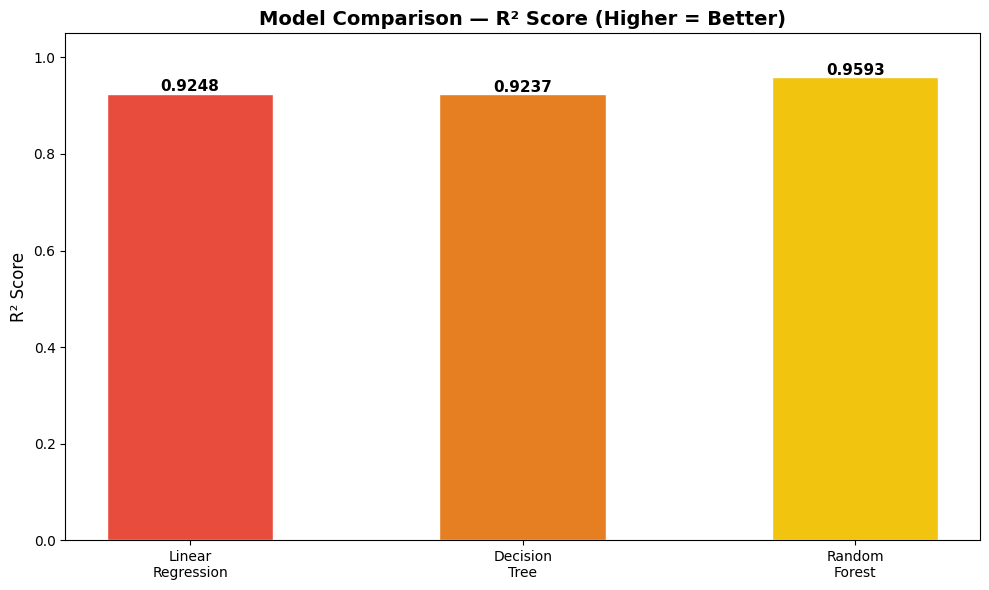


Best Model: Random Forest — R2 = 0.9593
Random Forest selected as the final model.


In [24]:
model_names = ['Linear\nRegression', 'Decision\nTree', 'Random\nForest', ]

r2_list = [
    r2_score(y_test, lr.predict(X_test)),
    r2_score(y_test, dt.predict(X_test)),
    r2_score(y_test, rf.predict(X_test)),

]

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#27ae60', '#3498db']

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, r2_list, color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, r2_list):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.ylim(0, 1.05)
plt.ylabel('R² Score', fontsize=12)
plt.title('Model Comparison — R² Score (Higher = Better)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

best = model_names[r2_list.index(max(r2_list))].replace('\n', ' ')
print(f"\nBest Model: {best} — R2 = {max(r2_list):.4f}")
print("Random Forest selected as the final model.")